In [18]:
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller,kpss 
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [19]:
DATA_PATH=Path("data/yahoo_stock_for_preprocessing.csv")
df=pd.read_csv(DATA_PATH,index_col='Date', parse_dates=True)
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1825 entries, 2015-11-23 to 2020-11-20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   High        1825 non-null   float64
 1   Low         1825 non-null   float64
 2   Open        1825 non-null   float64
 3   Close       1825 non-null   float64
 4   Volume      1825 non-null   float64
 5   Adj Close   1825 non-null   float64
 6   return      1824 non-null   float64
 7   log_return  1824 non-null   float64
dtypes: float64(8)
memory usage: 128.3 KB


In [20]:
df.index.dtype

dtype('<M8[us]')

In [21]:
assert df.index.is_monotonic_increasing

In [22]:
df=df.asfreq('B')
df.head(10)

,High,Low,Open,Close,Volume,Adj Close,return,log_return
Date,,,,,,,,
2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088,NaN,NaN
2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893,0.001222,0.001221
2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117,-0.000129,-0.000129
2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117,0.000000,0.000000
2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107,0.000594,0.000593
2015-11-30,2093.810059,2080.409912,2090.949951,2080.409912,4.275030e+09,2080.409912,-0.004641,-0.004652
2015-12-01,2103.370117,2082.929932,2082.929932,2102.629883,3.712120e+09,2102.629883,0.010681,0.010624
2015-12-02,2104.270020,2077.110107,2101.709961,2079.510010,3.950640e+09,2079.510010,-0.010996,-0.011057
2015-12-03,2085.000000,2042.349976,2080.709961,2049.620117,4.306490e+09,2049.620117,-0.014374,-0.014478


In [23]:
print(f'{len(df)}')

1305


In [24]:
df=df.drop(['return','log_return'],axis=1)

In [25]:
df=df.ffill()

### Quick sanity check

In [26]:
df.index.is_monotonic_increasing

True

In [27]:
df.isna().sum()

High         0
Low          0
Open         0
Close        0
Volume       0
Adj Close    0
dtype: int64

In [28]:
df.index.freq

<BusinessDay>

In [29]:
df.shape

(1305, 6)

### train/val/test split (70/15/15)

In [30]:
train_end=int(len(df)*0.70)
val_end = int(len(df) * 0.85)
print(train_end,val_end)

913 1109


In [31]:
train=df.iloc[:train_end]
val=df.iloc[train_end:val_end]
test=df.iloc[val_end:]

### check the len

In [32]:
print(f'Train: {len(train)} | Validation: {len(val)} | Test: {len(test)}')

Train: 913 | Validation: 196 | Test: 196


### ckeck date range

In [33]:
print(f'Train: {train.index.min()}  {train.index.max()} | Validation: {val.index.min()} {val.index.max()} | Test: {test.index.min()} {test.index.max()}')

Train: 2015-11-23 00:00:00  2019-05-22 00:00:00 | Validation: 2019-05-23 00:00:00 2020-02-20 00:00:00 | Test: 2020-02-21 00:00:00 2020-11-20 00:00:00


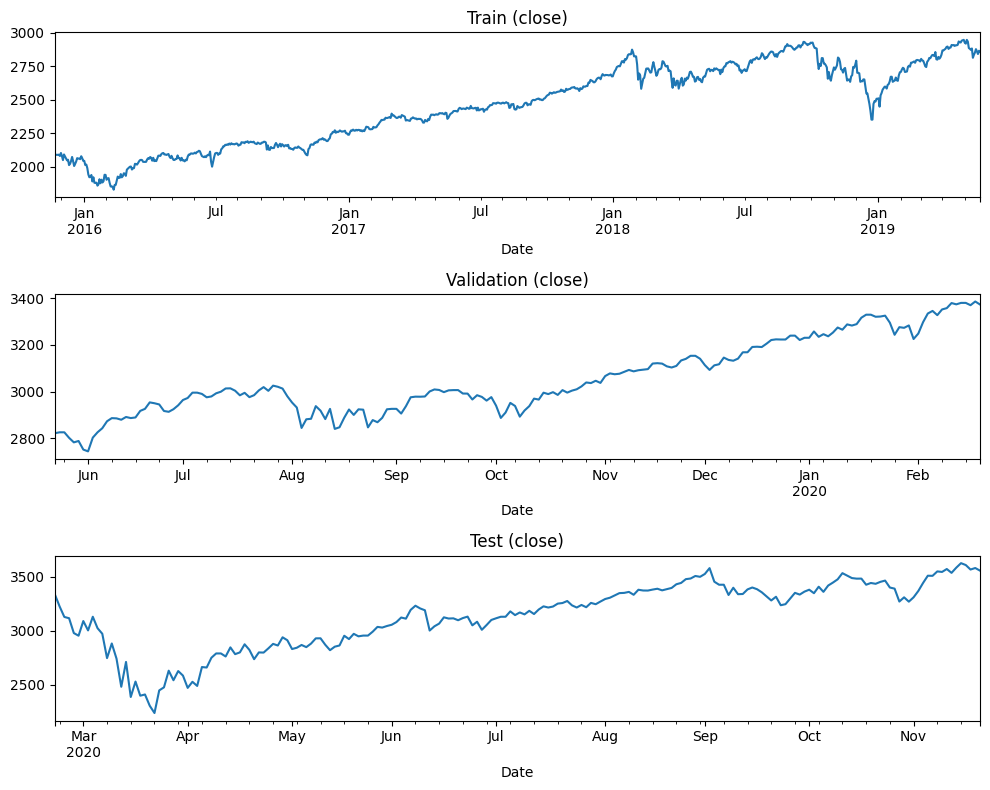

In [34]:
fig,axes = plt.subplots(3, 1, figsize=(10, 8))
train['Close'].plot(ax=axes[0],title='Train (close)')
val['Close'].plot(ax=axes[1],title='Validation (close)')
test['Close'].plot(ax=axes[2],title='Test (close)')
plt.tight_layout()
plt.show()

In [35]:
train.to_csv('data/train.csv')
val.to_csv('data/val.csv')
test.to_csv('data/test.csv')